# Tutorial

In the following tutorial, we show how to sample three types of SBMs and conduct percolation experiments. We also illustrate various utility functions.

Throughout, we will use $n$ (or `n`) for the number of nodes, $b$ (or `b`) for the vector of group assignments, $B$ (or `B`) for the number of groups, $n_b$ (or `nb[i]`) for the number of nodes in group $b$ (or `i`), and $P$ (or `P`) for connection probability matrices.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sbm_percolation import *

## Planted Partition SBMs

The function `connection_probability_matrix_planted_partition_sbm` generates $B\times B$ connection probability matrices $P$ for SBMs with within-group connection probability that can differ by group, and constant out-group connection probability. 

The function `generate_sbm` can sample graphs from such SBMs given a connection probability $P$ and a list that assigns nodes to groups. Note that nodes need to be sorted such that the list is non-decreasing.

We illustrate these functions below.

In [ ]:
# parameters
n = 10_000     # number of nodes
B = 2          # number of groups
p_in = 2e-3    # within group connection probability
p_out = 1e-3   # between group connection probability

seed = 1251    # random seed

In [ ]:
rng = np.random.default_rng(seed)

# assign nodes to groups and count the number of nodes per group
b = np.array([bb for bb in range(B) for _ in range(n // B)])
nb = np.bincount(b, minlength=B)

# compute the conneczztion probability matrix
P = connection_probability_matrix_planted_partition_sbm(
    p_ins=p_in * np.ones(B),  # list of within-group connection probabilities
    p_out=p_out,              # between-group connection probability
    B=B                       # number of groups
)

# sample a graph from the SBM
edges = generate_sbm(
    b=b,
    P=P,
    rng=rng,
    algorithm="mh"
)

# compute the average degree
m = len(edges)
print(f"Average degree: {2*m / n:.2f}")

Average degree: 15.01


Considering sequences of such SBMs in which the clustering vanishes, we one can compute the percolation threshold from the largest eigenvalue of the connectivity matrix $M$. Below we illustrate how to construct this matrix and find its largest eigenvalue.

In [48]:
# build connectivity matrix M
M = build_matrix_M(
    nb=nb,   # number of nodes per group
    P=P      # connection probability matrix
)

# find largest eigenvalue and corresponding eigenvector of M
lam_max, v_max, converged = power_iteration(M)

if converged:
    print(f"Largest eigenvalue: {lam_max:.2f}")
else:
    print("Power iteration did not converge.")

Largest eigenvalue: 15.00


For certain connectivity matrices the largest eigenvalue can be easily computed analytically using the function `lam_theo`. This function is taylored to the cases studied in the paper and supports `sbm_type` equal to `const`, `sqrt`, and `tree`.  

In [49]:
lam_max = lam_theo((p_in*np.ones(B), p_out, n), sbm_type="const")

print(f"Largest eigenvalue: {lam_max:.2f}")

Largest eigenvalue: 15.00


For the special case of SBMs with constant number of nodes $s$ per group as $n \to \infty$, fixed within-group connection probability `p_in`, between group connectivity scaling as $p_\mathrm{out} ~ \frac{q}{n}$, the critical value of $q$ can be computed approximately using the function `critical_q`. The function supports to solve the relevant equations using recursion (`method="recursive"`), sampling (`method="numeric"`), or using closed form approximate expressions (`method="analytical"`) in linearized (`linearized=True`) or non-linearized form (`linearized=False`). For most parameter regimes we recommend the recursive linearized approach.

For details on other approaches refer to the docstring using `critical_q?`.

In [57]:
qc = critical_q(
    p_in=0.05,
    s=5,
    method='recursive',
    linearized=True
)

print(f"Critical q: {qc:.3f}")

Critical q: 0.812


## Tree-Structured SBMs

Specifying a tree structured SBM means fixing a branching factor $a$ and the between-group connectivity parameter $c_\mathrm{out}$, and the number of groups $B$. The branching factor and the number of groups implicitly determine the number of nodes $n$. Note that $c_out \leq a$ is required.

The function `connection_probability_matrix_rootedtree_sbm` generates connection probability matrices from these parameters. The utility function `balanced_tree_nodes(a, B-1)` can be used to compute the number of nodes.

In [8]:
# parameters
a = 2          # branching factor
B = 15         # number of groups
c_out = 1.5    # between group connectivity

seed = 1251    # random seed

In [10]:
# initialize random number generator
rng = np.random.default_rng(seed)

# compute the number of nodes
n = balanced_tree_nodes(
    a=a,
    L=B-1
)

# number of nodes per group
nb = np.power(a, np.arange(0, B), dtype=int)

# assignment of nodes to groups
b = np.array([bb for bb in range(B) for _ in range(nb[bb])])

# compute the connection probability matrix
P = connection_probability_matrix_rootedtree_sbm(
    a=a,
    c_out=c_out,
    B=B
)

# sample a graph from the SBM
edges = generate_sbm(
    b=b,
    P=P,
    rng=rng,
    algorithm="mh"
)

# compute the average degree
m = len(edges)
print(f"Average degree: {2*m / n:.2f}")
print(f"Number of nodes: {n}")

Average degree: 1.50
Number of nodes: 32767


As tree-structured SBMs have zero clustering, the largest eigenvalue of the connectivity matrix governs their percolation transition. It can be calculated analytically, using that the connectivity matrix is a circulant matrix.

In [67]:
# find the largest eigenvalue using closed form expression for circulant matrices
lam_max_theo = lam_theo((a, c_out, n), sbm_type="tree")

print(f"Largest eigenvalue: {lam_max_theo:.2f}")

Largest eigenvalue: 2.12


## Geometric SBMs

The geometric SBM is a discretization of soft random geometric graphs (SRGGs). It is parameterized by a density parameter $c$, the number of nodes per group $s$, and the inverse temperature $\beta$, as well as the number of nodes $n$.

A connection probability at a distance of `x` blocks away can be computed using `connection_probability_discretized_srgg` and the entire connection probability matrix using `connection_probability_matrix_discretized_srgg`. While both function support numerical integration (`average="numerical"`) of the SRGG connection probability function, using analytical expression (`average="analytical"`) is preferred.

As the number of groups is large the setting `algorithm="mh"` in `generate_sbm` can be advantageous.

In [ ]:
# parameters
n = 10_000   # number of nodes
c = 2.0      # connectivity parameter
beta = 1.5   # inverse temperature
s = 10       # number of nodes per group

seed = 1251  # random seed

In [ ]:
# assign nodes to groups and count the number of nodes per group
B = n // s
b = np.array([bb for bb in range(B) for _ in range(s)])
nb = np.bincount(b, minlength=B)

# compute the connection probability matrix
P = connection_probability_matrix_discretized_srgg(
    n=n,
    c=c,
    beta=beta,
    s=s
)

In [ ]:
# initialize random number generator
rng = np.random.default_rng(seed)

# sample a graph from the geometric SBM
edges_sbm = generate_sbm(
    b=b,
    P=P,
    rng=rng,
    algorithm="mh"
)

To facilitate comparison between graphs from the geometric SBM and from the SRGG model, we provide the function `generate_srgg` to sample graphs from the latter as well as the function `average_degree_srgg`.

In [78]:
edges_srgg = generate_srgg(
    n=n,
    c=c,
    beta=beta,
    rng=rng
)

In [83]:
kbar_exp_sbm = 2 * len(edges_sbm) / n
kbar_exp_srgg = 2 * len(edges_srgg) / n

kbar_theo_sbm = average_degree_sbm(nb, P, degree_type="total")
kbar_theo_srgg = average_degree_srgg(c, beta, n)

print(f"Average degree SBM: {kbar_exp_sbm:.2f} (expected: {kbar_theo_sbm:.2f})")
print(f"Average degree SRGG: {kbar_exp_srgg:.2f} (expected: {kbar_theo_srgg:.2f})")

Average degree SBM: 11.26 (expected: 11.24)
Average degree SRGG: 11.87 (expected: 11.84)


To study percolation, we implement `critical_c` to compute the critical value of the connectivity parameter `c` for the geometric SBM. It supports the same approaches to solving the relevant equations as `critical_q` (see section Planted Partition SBM).

In [86]:
cc = critical_c(
    beta=beta,
    s=s,
    method="recursive",
    linearized=True
)

print(f"Critical c: {cc:.3f}")

Critical c: 0.239


## Percolation Simulations

The central element of our percolation simulations is the function `percolate` that uses a union-find datastructure to determine the connected component in a graph provided as an edge list.

In [114]:
# parameters
n = 10_000     # number of nodes
B = 2          # number of groups
p_in = 2e-4  # within group connection probability
p_out = 1e-4 # between group connection probability

seed = 123    # random seed

In [115]:
# initialize random number generator
rng = np.random.default_rng(seed)

# assign nodes to groups and count the number of nodes per group
b = np.array([bb for bb in range(B) for _ in range(n // B)])
nb = np.bincount(b, minlength=B)

# compute the connection probability matrix
P = connection_probability_matrix_planted_partition_sbm(
    p_ins=p_in * np.ones(B),  # list of within-group connection probabilities
    p_out=p_out,              # between-group connection probability
    B=B                       # number of groups
)

# sample a graph from the SBM
edges = generate_sbm(
    b=b,
    P=P,
    rng=rng,
    algorithm="mh"
)

In [116]:
# compute the component sizes of the graph
component_sizes = percolate(edges, n)

print(f"Number of connected components: |C| = {len(component_sizes)}")
print(f"Size of the largest connected component: n_lcc = {max(component_sizes)}")
print(f"Relative Size of the largest connected component: xi = {max(component_sizes)/n:.3f}")
print(f"Susceptibility: chi = {np.sum(np.power([c for i,c in enumerate(component_sizes) if i!=np.argmax(component_sizes)], 2))/n:.3f}")

Number of connected components: |C| = 2720
Size of the largest connected component: n_lcc = 6056
Relative Size of the largest connected component: xi = 0.606
Susceptibility: chi = 1.038


## Other Utility Functions

We further utility functions that can be useful.

#### Visualizing Connection Probability Functions

For visualizations of the connection probability function that take into account group size the function `connection_probability_matrix_group_to_node` maps $B\times B$ connection probability matrices to $N \times N$ matrices. We illustrate this for the tree structured SBM.

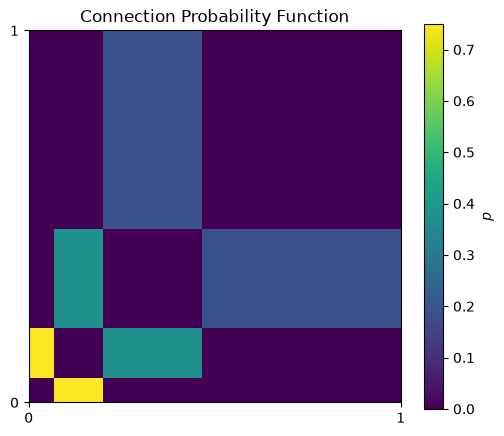

In [135]:
# parameters
a = 2          # branching factor
B = 4          # number of groups
c_out = 1.5    # between group connectivity

# compute the connection probability matrix (BxB)
n = balanced_tree_nodes(
    a=a,
    L=B-1
)
nb = np.power(a, np.arange(0, B), dtype=int)
b = np.array([bb for bb in range(B) for _ in range(nb[bb])])
PB = connection_probability_matrix_rootedtree_sbm(
    a=a,
    c_out=c_out,
    B=B
)



# for visualization NxN connection probability "function"
PN = connection_probability_matrix_group_to_node(PB, b)

# visualize
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)
im = ax.imshow(PN, cmap="viridis", vmin=0, vmax=np.max(PN))
ax.set_yinverted(False)
ax.set_yticks([0-0.5, n-0.5], ["0", "1"])
ax.set_xticks([0-0.5, n-0.5], ["0", "1"])
ax.set_title("Connection Probability Function")
cbar = fig.colorbar(im)
cbar.set_label(r"$p$")

#### Average Degree

The function `average_degree_sbm` computes the average degree, average within-group degree, and average between-group degree for arbitrary connection probability matrices.

In [138]:
# parameters
n = 10_000     # number of nodes
B = 2          # number of groups
p_in = 2e-3    # within group connection probability
p_out = 1e-3   # between group connection probability

# assign nodes to groups and count the number of nodes per group
b = np.array([bb for bb in range(B) for _ in range(n // B)])
nb = np.bincount(b, minlength=B)

# compute the conneczztion probability matrix
P = connection_probability_matrix_planted_partition_sbm(
    p_ins=p_in * np.ones(B),  # list of within-group connection probabilities
    p_out=p_out,              # between-group connection probability
    B=B                       # number of groups
)

# average degree
ktot = average_degree_sbm(nb, P, degree_type="total")
kin = average_degree_sbm(nb, P, degree_type="in")
kout = average_degree_sbm(nb, P, degree_type="out")

print(f"Average total degree: {ktot:.2f}")
print(f"Average in-group degree: {kin:.2f}")
print(f"Average out-group degree: {kout:.2f}")

Average total degree: 15.00
Average in-group degree: 10.00
Average out-group degree: 5.00


#### Clustering Coefficient & Transitivity

We also provide functions that compute the clustering of an SBM with a given connection probability matrix (via Monte Carlo sampling) and functions to compute the clustering coefficient and transitivity of a given graph. 

In [158]:
# parameters
n = 10_000     # number of nodes
B = 2          # number of groups
p_in = 5e-3    # within group connection probability
p_out = 2e-3   # between group connection probability
seed = 13431   # random seed

# assign nodes to groups and count the number of nodes per group
b = np.array([bb for bb in range(B) for _ in range(n // B)])
nb = np.bincount(b, minlength=B)

# compute the conneczztion probability matrix
P = connection_probability_matrix_planted_partition_sbm(
    p_ins=p_in * np.ones(B),  # list of within-group connection probabilities
    p_out=p_out,              # between-group connection probability
    B=B                       # number of groups
)



In [160]:
# compute the expected clustering in the moel
clustering_theo = clustering_coefficient_theoretical(
    P=P,                        # connection probability matrix
    nb=nb,                      # number of nodes per group
    num_samples=int(1e4),       # number of Binomial samples per root group
    exchangeable_groups=False,  # if groups are exchangeable only one root group is sampled
    verbose=False               # whether to print progress of the computation     
)

print(f"Expected clustering coefficient: {clustering_theo:.5f}")

Expected clustering coefficient: 0.00377


In [161]:
# sample a graph from the SBM
edges = generate_sbm(
    b=b,
    P=P,
    rng=np.random.default_rng(seed),
    algorithm="mh"
)

In [ ]:
# convert to adjacency matrix
A = edgelist_to_adjacency(n, edges)

# compute the average local clustering coefficient
clustering_exp = clustering_coefficient(A)

# compute the transitivity of the graph
transitivity_exp = transitivity(A)

print(f"Average local clustering coefficient: {clustering_exp:.5f}")
print(f"Transitivity: {transitivity_exp:.5f}")

Average local clustering coefficient: 0.0038
Transitivity: 0.0037
